# Model 1 — Shooting Counts per Tract (Poisson / Negative Binomial)

**ISYE 6414 — Final Project | NYC Census-Tract Gun Violence**

**Unit of analysis:** NYC census tract (2020 boundaries), five boroughs.

**This notebook is self-contained:** it loads, cleans, and merges the raw data, performs
EDA and outlier screening, splits into train/validation/test, selects variables using the
validation set, checks model assumptions, and reports final metrics on the held-out test
set. Set the random seed to `6414`; run top-to-bottom to reproduce every result.




**Outcome:** `shooting_count` — number of unique shooting incidents per tract (a non-negative count). We model it with a **Poisson GLM using a population offset** `log(total_population)` so coefficients describe the *rate* per person; if the counts are overdispersed we switch to a **Negative Binomial** GLM.

## 1. Load, Clean & Merge the Data

The analysis dataset is assembled from four sources, joined on the 11-digit census-tract
GEOID (see [`data/README.md`](../data/README.md) for full provenance):

| Source | Contributes | Join |
|---|---|---|
| **NYPD** Shooting Incident data (Shootings + Victims + Offenders) | shooting incidents | `INCIDENT_KEY`, then a spatial join of geocoded points into tracts |
| **ACS** 5-year 2024 (DP05, S1501, S1701, S1901, S2301) | demographics, education, poverty, income, employment | `GEO_ID` |
| **CDC/ATSDR** Social Vulnerability Index (NY) | housing, insurance, disability, single-parent, etc. | tract FIPS |
| **TIGER/Line** 2024 tract shapefile | tract polygons | used for the spatial join |

`build_dataset()` (in [`src/dataprep.py`](../src/dataprep.py)) runs this pipeline:
NYPD triple-join → ACS 5-table join → CDC SVI join → spatial join of incidents to tracts
→ aggregate to per-tract counts → keep the five NYC boroughs → derive outcomes → drop
incomplete cases.

> **Coordinate quirk (handled):** in the NYPD export the `Latitude`/`Longitude` columns
> are swapped; `spatial_join_counts()` builds points as (x=`Latitude`, y=`Longitude`).
> Without the fix every tract count would be zero.


**Dependencies:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`, `scipy`, `scikit-learn`, `geopandas`, `pygris`

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
warnings.filterwarnings("ignore")

# Locate the repo root so `src` imports and output paths work whether this notebook
# is launched from the repo root or from notebooks/.
_cwd = os.getcwd()
ROOT = next((c for c in (_cwd, os.path.dirname(_cwd)) if os.path.isdir(os.path.join(c, "src"))), _cwd)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.dataprep import build_dataset, PREDICTORS, PATHS
from src.modeling import (split_data, zscore_fit, zscore_apply,
                          stepwise_select_by_validation, vif_table)

SEED = 6414
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.width", 120)
print(f"{len(PREDICTORS)} candidate predictors loaded")

17 candidate predictors loaded


In [2]:
# build_dataset() runs the full raw -> processed pipeline on first call (NYPD triple-join,
# ACS 5-table join, CDC SVI join, spatial join to tracts, borough filter, outcome
# derivation) and caches the result. Pass force=True to rebuild from raw.
df = build_dataset()

# The rate outcome and the count model's population offset both require a positive
# denominator, so drop the handful of zero-population tracts.
df = df[df["total_population"] > 0].reset_index(drop=True)
print("Analysis-ready tracts:", df.shape[0], "| columns:", df.shape[1])
df[["tract_geoid", "nyc_borough_county", "shooting_count",
    "shooting_rate_per_1000", "high_shooting_tract"]].head()

Analysis-ready tracts: 2185 | columns: 34


,tract_geoid,nyc_borough_county,shooting_count,shooting_rate_per_1000,high_shooting_tract
0,36005000200,Bronx,1.0,0.197589,0
1,36005000400,Bronx,7.0,1.052790,0
2,36005001600,Bronx,22.0,3.920870,1
3,36005001901,Bronx,7.0,3.097345,1
4,36005001902,Bronx,18.0,8.658009,1


**Leakage guard:** When modeling one shooting outcome, we never use the other derived shooting outcomes or the raw shooting count as predictors. The 17 candidate predictors consist only of ACS and CDC socioeconomic and demographic measures. Total population is incorporated separately as an exposure offset rather than as a predictor, allowing the model to account for differences in the population at risk across census tracts.

This prevents information from the outcome variable from leaking into the predictors and ensures that the models estimate shooting rates while accounting for differences in tract population.


## 2. Exploratory Data Analysis

Shooting counts are non-negative count data and are right-skewed, with many tracts experiencing relatively few shootings and a smaller number of tracts having substantially higher counts. Totals also vary considerably across boroughs. These characteristics motivate the use of count regression models such as Poisson and Negative Binomial regression, with the Negative Binomial model providing a potential alternative if the observed variability exceeds the mean-variance relationship assumed by the Poisson model.

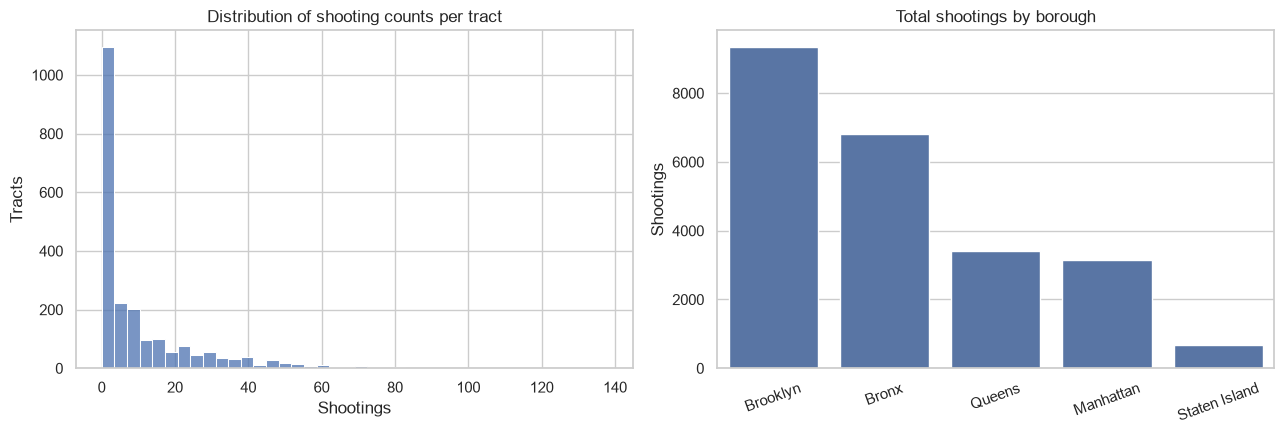

,tracts,total_shootings,mean_count
nyc_borough_county,,,
Brooklyn,765,9356.0,12.230065
Bronx,339,6819.0,20.115044
Queens,675,3414.0,5.057778
Manhattan,288,3140.0,10.902778
Staten Island,118,669.0,5.669492


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["shooting_count"], bins=40, ax=ax[0])
ax[0].set(title="Distribution of shooting counts per tract", xlabel="Shootings", ylabel="Tracts")
bor = (df.groupby("nyc_borough_county")
         .agg(tracts=("shooting_count", "size"),
              total_shootings=("shooting_count", "sum"),
              mean_count=("shooting_count", "mean"))
         .sort_values("total_shootings", ascending=False))
sns.barplot(x=bor.index, y=bor["total_shootings"], ax=ax[1])
ax[1].set(title="Total shootings by borough", xlabel="", ylabel="Shootings")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(PATHS["figures"] / "m1_eda_counts.png", dpi=150, bbox_inches="tight"); plt.show()
bor

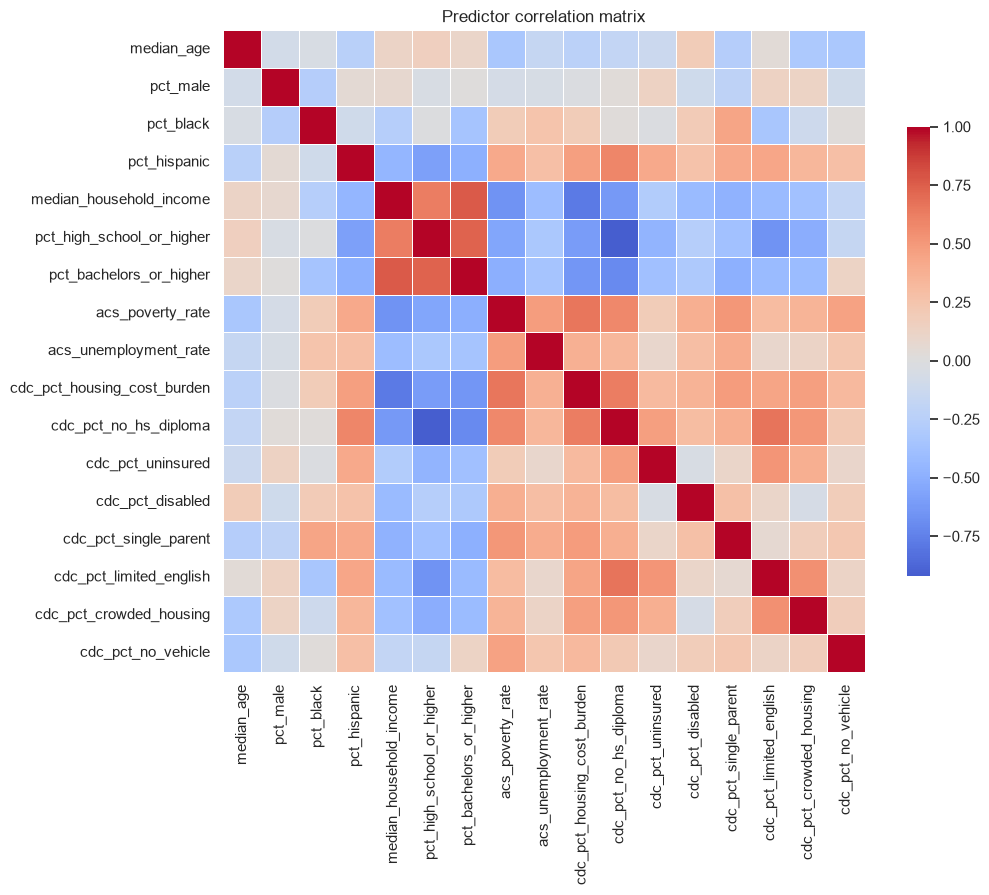

In [4]:
# Multicollinearity screen: several CDC SVI percentages measure overlapping social
# vulnerability, so we expect strong correlations (revisited via VIF later).
plt.figure(figsize=(11, 9))
sns.heatmap(df[PREDICTORS].corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .7}, linewidths=.5)
plt.title("Predictor correlation matrix")
plt.tight_layout()
plt.savefig(PATHS["figures"] / "eda_predictor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Train / Validation / Test Split

We split the data into training (60%), validation (20%), and test (20%) sets using seed `6414`. The training set is used to fit the models, the validation set is used for variable selection and model decisions, and the test set is reserved exclusively for the final evaluation of predictive performance.

Predictors are standardized using means and standard deviations calculated from the training set only. The same training-set scaling parameters are then applied to the validation and test sets. This prevents information from the validation or test sets from influencing model fitting or preprocessing and helps avoid data leakage.

In [5]:
# 60 / 20 / 20 split with a fixed seed. Predictors are standardized using TRAIN-only
# mean/sd (fit on train, applied to val/test) so no information leaks from the held-out
# data into preprocessing.
train, valid, test = split_data(df, seed=SEED)
mean_, std_ = zscore_fit(train, PREDICTORS)
train = zscore_apply(train, PREDICTORS, mean_, std_)
valid = zscore_apply(valid, PREDICTORS, mean_, std_)
test  = zscore_apply(test,  PREDICTORS, mean_, std_)
print(f"train={len(train)}  valid={len(valid)}  test={len(test)}")

train=1311  valid=437  test=437


### 3a. Multicollinearity screen (VIF)

The correlation heatmap in Section 2 showed several CDC SVI percentages measuring
overlapping dimensions of social vulnerability. We formally check multicollinearity
via variance inflation factors (VIF) on the standardized training predictors before
proceeding to outlier screening and variable selection.

In [6]:
vif_df = vif_table(train, PREDICTORS)
print(vif_df.to_string(index=False))

                   variable      VIF
      cdc_pct_no_hs_diploma 7.299246
  pct_high_school_or_higher 7.275315
    pct_bachelors_or_higher 7.093858
    median_household_income 4.417494
cdc_pct_housing_cost_burden 3.514248
    cdc_pct_limited_english 3.125057
           acs_poverty_rate 2.944301
         cdc_pct_no_vehicle 2.445180
                  pct_black 2.418811
      cdc_pct_single_parent 2.143895
               pct_hispanic 2.140433
    cdc_pct_crowded_housing 1.913790
           cdc_pct_disabled 1.685479
                 median_age 1.670135
          cdc_pct_uninsured 1.582637
      acs_unemployment_rate 1.412610
                   pct_male 1.189223


## 4. Outlier Screening & Handling

We first establish overdispersion, then screen for potentially influential tracts using Cook's distance from the Negative Binomial model. Because the Poisson model assumes equidispersion and may underestimate variability when the data are overdispersed, the Negative Binomial specification provides a more appropriate basis for influence diagnostics. Tracts exceeding the conventional $4/n$ cutoff are removed from the training data only, while the validation and test sets remain unchanged.

Poisson Pearson dispersion (>1 => overdispersed): 7.52
NB alpha = 0.662 | influential tracts (Cook's D > 4/n): 100 of 1311


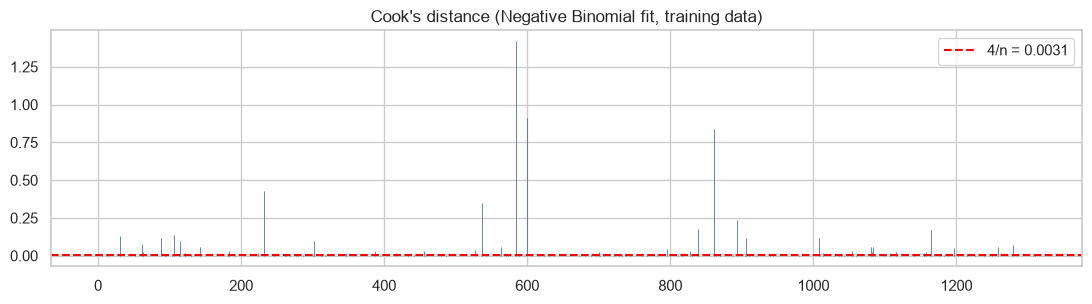

In [7]:
X_tr = sm.add_constant(train[PREDICTORS].astype(float))
offset_tr = np.log(train["total_population"])

pois0 = sm.GLM(train["shooting_count"], X_tr, family=sm.families.Poisson(), offset=offset_tr).fit()
dispersion = (pois0.resid_pearson ** 2).sum() / pois0.df_resid
print(f"Poisson Pearson dispersion (>1 => overdispersed): {dispersion:.2f}")

nb_mle = sm.NegativeBinomial(train["shooting_count"], X_tr, offset=offset_tr).fit(disp=0, maxiter=200)
alpha = float(nb_mle.params["alpha"])
nb0 = sm.GLM(train["shooting_count"], X_tr,
             family=sm.families.NegativeBinomial(alpha=alpha), offset=offset_tr).fit()
cooks = nb0.get_influence().cooks_distance[0]
thresh = 4 / len(train)
flag = cooks > thresh
print(f"NB alpha = {alpha:.3f} | influential tracts (Cook's D > 4/n): {int(flag.sum())} of {len(train)}")

plt.figure(figsize=(11, 3.2))
plt.vlines(np.arange(len(cooks)), 0, cooks, lw=.6)
plt.axhline(thresh, color="red", ls="--", label=f"4/n = {thresh:.4f}")
plt.title("Cook's distance (Negative Binomial fit, training data)"); plt.legend()
plt.tight_layout(); plt.show()

**Before/after check:** the removal above is driven by a multivariate influence/residual rule,
not a per-variable rule, so we visualize its effect on the distribution of each standardized
predictor directly: box plots of all 17 predictors, using training rows only, before removal
(top) and after removal (bottom), with a fixed y-axis so that any apparent narrowing reflects
the removal of observations rather than autoscaling.

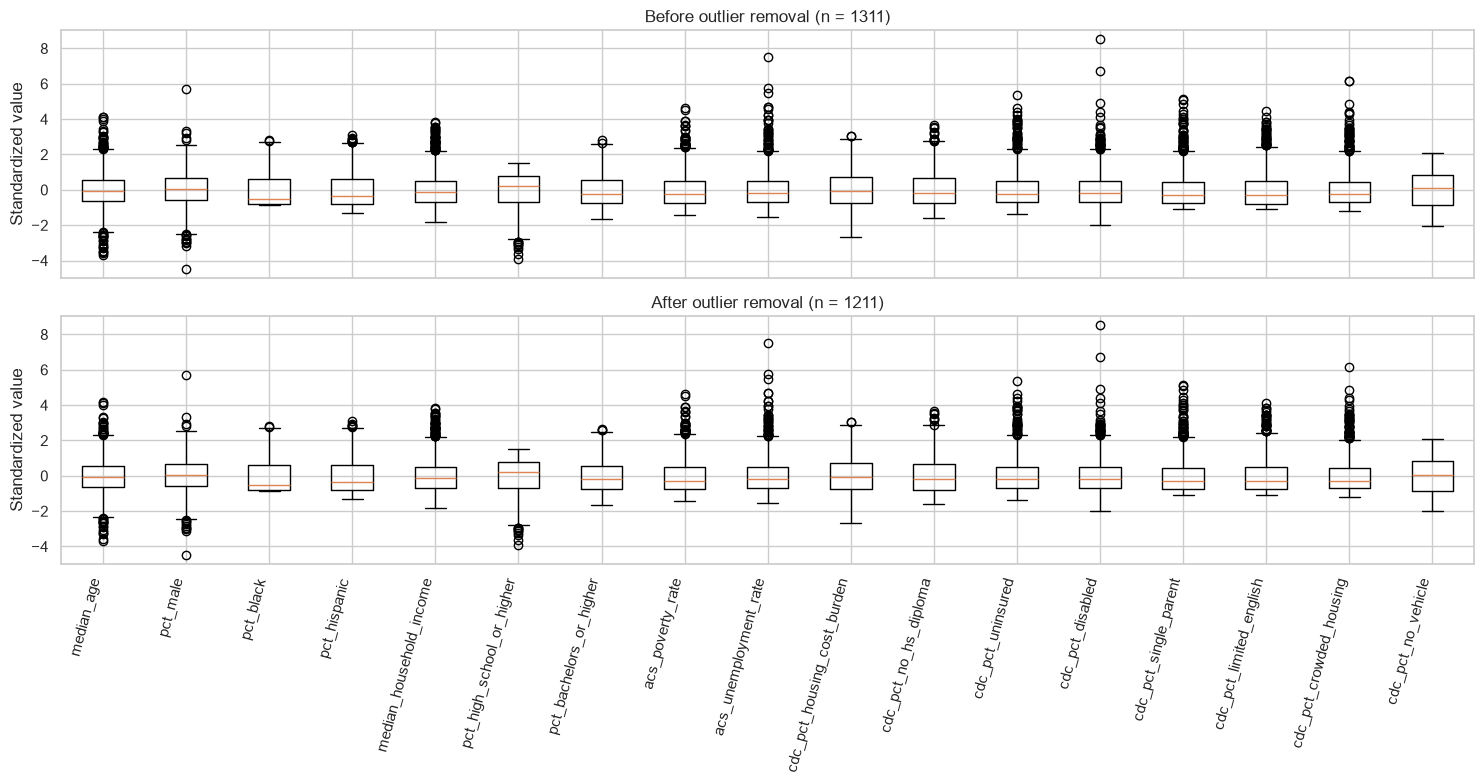

In [8]:
# Row 1 = training predictors before removal, Row 2 = the same predictors after removal.
# The y-axis is fixed to the pre-removal range so any narrowing in row 2 reflects the
# points the outlier-screening step actually removed, not autoscaling.
before = train[PREDICTORS]
after = train.loc[~flag, PREDICTORS]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ylo, yhi = before.min().min() - 0.5, before.max().max() + 0.5
for ax, data, label in zip(axes, [before, after], ["Before outlier removal", "After outlier removal"]):
    ax.boxplot([data[c].dropna() for c in PREDICTORS], showfliers=True)
    ax.set_title(f"{label} (n = {len(data)})")
    ax.set_ylabel("Standardized value")
    ax.set_ylim(ylo, yhi)
    ax.set_xticks(range(1, len(PREDICTORS) + 1))
    ax.set_xticklabels(PREDICTORS, rotation=75, ha="right")
plt.tight_layout()
plt.savefig(PATHS["figures"] / "m1_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
train = train.loc[~flag].reset_index(drop=True)
print("Training tracts after outlier removal:", len(train))

Training tracts after outlier removal: 1211


## 5. Variable Selection (Validation-Driven)

Starting from all 17 candidate predictors, we run bidirectional stepwise selection using validation-set Poisson deviance as the selection criterion. This uses validation-set performance to favor predictors that improve predictive performance on held-out data and helps reduce overfitting. The procedure retains 8 of the 17 candidate predictors for the final model.

In [10]:
def fit_count(tr, preds):
    X = sm.add_constant(tr[preds].astype(float))
    return sm.GLM(tr["shooting_count"], X, family=sm.families.Poisson(),
                  offset=np.log(tr["total_population"])).fit()

def val_deviance(model, va):
    preds = [p for p in model.model.exog_names if p != "const"]
    X = sm.add_constant(va[preds].astype(float))
    mu = model.predict(X, offset=np.log(va["total_population"]))
    y = va["shooting_count"].to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        term = np.where(y > 0, y * np.log(y / mu), 0.0)
    return float(2 * np.sum(term - (y - mu)))

selected, _, val_score, history = stepwise_select_by_validation(
    fit_count, val_deviance, PREDICTORS, train, valid, verbose=True)
print(f"\nSelected {len(selected)} predictors | validation deviance = {val_score:.1f}")
print(selected)

start: 17 predictors | val score = 2403.71775
- cdc_pct_uninsured    -> 16 preds | val score = 2343.24111
- pct_male             -> 15 preds | val score = 2274.44144
- acs_unemployment_rate -> 14 preds | val score = 2255.52087
- cdc_pct_no_hs_diploma -> 13 preds | val score = 2243.59094
- pct_high_school_or_higher -> 12 preds | val score = 2207.76033
- acs_poverty_rate     -> 11 preds | val score = 2194.62715
- cdc_pct_single_parent -> 10 preds | val score = 2193.17007
- median_age           -> 9 preds | val score = 2187.63724
- cdc_pct_housing_cost_burden -> 8 preds | val score = 2183.82404

Selected 8 predictors | validation deviance = 2183.8
['pct_black', 'pct_hispanic', 'median_household_income', 'pct_bachelors_or_higher', 'cdc_pct_disabled', 'cdc_pct_limited_english', 'cdc_pct_crowded_housing', 'cdc_pct_no_vehicle']


**Interpretation:**

The stepwise selection procedure retained **8** of the 17 candidate predictors because this combination produced the **lowest validation-set Poisson deviance** (2183.8, down from 2403.7 with all 17 predictors) among the models considered. The selected predictors are:

- `pct_black`
- `pct_hispanic`
- `median_household_income`
- `pct_bachelors_or_higher`
- `cdc_pct_disabled`
- `cdc_pct_limited_english`
- `cdc_pct_crowded_housing`
- `cdc_pct_no_vehicle`

These variables collectively provided the best predictive performance on the validation data under the Poisson model. Their inclusion indicates that, collectively, these predictors contributed to improved validation-set predictive performance relative to the candidate models considered. However, selection by the stepwise procedure should not be interpreted as evidence of a causal relationship or as indicating that each selected predictor is individually statistically significant. Rather, the selected set represents the combination of variables that achieved the best validation-set predictive performance among the models considered.

### 5a. Variable Selection Robustness Check: LASSO-Regularized Poisson Regression

As a third comparison, we fit an L1-regularized (LASSO) Poisson generalized linear model (GLM), which performs variable selection by shrinking coefficients toward zero rather than through significance testing or AIC-based model selection. Predictors were already standardized using the training-set means and standard deviations, so no additional scaling was required. The population offset and intercept were left unpenalized. The regularization parameter was selected by minimizing validation-set Poisson deviance, providing an additional variable-selection approach to assess the stability of the selected predictors.

*Note: Because L1-regularized models do not provide standard errors or p-values for the penalized coefficients, LASSO is used here to assess the robustness of variable selection rather than to replace the inferential analyses presented later in this notebook.*

In [11]:
Xtr_const = sm.add_constant(train[PREDICTORS].astype(float))
off_train_lasso = np.log(train["total_population"])

alphas = np.logspace(-4, 0, 20)
lasso_results = []

for a in alphas:
    alpha_vec = np.array([0.0] + [a] * len(PREDICTORS))
    fit = sm.GLM(train["shooting_count"], Xtr_const, offset=off_train_lasso,
                 family=sm.families.Poisson()).fit_regularized(
        alpha=alpha_vec, L1_wt=1.0, maxiter=1000, cnvrg_tol=1e-8)
    Xva_const = sm.add_constant(valid[PREDICTORS].astype(float))
    mu_val = np.exp(Xva_const.values @ fit.params.values + np.log(valid["total_population"]).values)
    y_val = valid["shooting_count"].to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        term = np.where(y_val > 0, y_val * np.log(y_val / mu_val), 0.0)
    dev_val = float(2 * np.sum(term - (y_val - mu_val)))
    n_nonzero = int(np.sum(np.abs(fit.params.values[1:]) > 1e-6))
    lasso_results.append({"alpha": a, "val_deviance": dev_val, "n_nonzero": n_nonzero})

lasso_df = pd.DataFrame(lasso_results)
print(lasso_df)

best_alpha = lasso_df.loc[lasso_df["val_deviance"].idxmin(), "alpha"]
print(f"\nBest alpha (min validation deviance): {best_alpha:.5f}")

alpha_vec_best = np.array([0.0] + [best_alpha] * len(PREDICTORS))
final_lasso = sm.GLM(train["shooting_count"], Xtr_const, offset=off_train_lasso,
                      family=sm.families.Poisson()).fit_regularized(
    alpha=alpha_vec_best, L1_wt=1.0)

lasso_coefs = pd.Series(final_lasso.params.values[1:], index=PREDICTORS)
lasso_selected = lasso_coefs[np.abs(lasso_coefs) > 1e-6].index.tolist()
lasso_dropped = lasso_coefs[np.abs(lasso_coefs) <= 1e-6].index.tolist()

print(f"\nLASSO-selected predictors ({len(lasso_selected)}): {lasso_selected}")
print(f"LASSO-dropped predictors ({len(lasso_dropped)}): {lasso_dropped}")

stepwise_set = set(selected)
lasso_set = set(lasso_selected)
print(f"\nIn stepwise (Sec. 5) but not LASSO: {sorted(stepwise_set - lasso_set)}")
print(f"In LASSO but not stepwise: {sorted(lasso_set - stepwise_set)}")
print(f"In both: {sorted(stepwise_set & lasso_set)}")

       alpha  val_deviance  n_nonzero
0   0.000100   2403.598449         17
1   0.000162   2403.524062         17
2   0.000264   2403.403330         17
3   0.000428   2403.207436         17
4   0.000695   2402.889736         17
5   0.001129   2402.374887         17
6   0.001833   2374.166513         16
7   0.002976   2400.195610         17
8   0.004833   2381.957488         16
9   0.007848   2394.559754         17
10  0.012743   2389.056777         17
11  0.020691   2384.792468         16
12  0.033598   2349.418460         15
13  0.054556   2326.824333         13
14  0.088587   2229.217530         12
15  0.143845   2230.659910         10
16  0.233572   2383.199668          6
17  0.379269   2413.790840          7
18  0.615848   2472.501699          7
19  1.000000   2579.853566          6

Best alpha (min validation deviance): 0.08859

LASSO-selected predictors (12): ['median_age', 'pct_black', 'pct_hispanic', 'median_household_income', 'pct_high_school_or_higher', 'acs_poverty_rate', 'c

**Interpretation:**

LASSO selects a notably larger set of predictors than the validation-driven stepwise procedure, retaining 12 of the 17 candidate predictors compared with 8 for stepwise. This difference illustrates that variable selection depends on the selection method and optimization objective: stepwise search and L1 regularization optimize different criteria, so there is no guarantee that a more heavily regularized method will produce a smaller model for a given dataset. Seven predictors are common to both approaches. `pct_bachelors_or_higher` is retained only by stepwise, whereas `acs_poverty_rate`, `cdc_pct_housing_cost_burden`, `cdc_pct_no_hs_diploma`, `median_age`, and `pct_high_school_or_higher` are retained only by LASSO. Statistical significance and predictive variable selection are not equivalent: a variable may be statistically significant in a fitted model without being retained by a predictive selection procedure, while a variable selected through regularization should not automatically be interpreted as having an independent or causal effect.

Notably, LASSO retains `acs_poverty_rate`, whereas the primary validation-driven stepwise procedure does not. This suggests that, under the LASSO selection criterion, poverty provides incremental predictive information that was not retained by the stepwise procedure. However, this difference is method-dependent and should not be interpreted as evidence that poverty has an independent or causal effect on shooting rates.

## 6. Final Model, Goodness-of-Fit & Assumption Checks

We refit the selected model on **train + validation** as a Negative Binomial GLM (the overdispersion-appropriate family), then check goodness-of-fit via the deviance statistic.

In [12]:
trainval = pd.concat([train, valid], ignore_index=True)
Xtv = sm.add_constant(trainval[selected].astype(float))
off_tv = np.log(trainval["total_population"])

# Re-estimate NB alpha on train+val for the selected predictors
alpha_final = float(sm.NegativeBinomial(trainval["shooting_count"], Xtv, offset=off_tv)
                    .fit(disp=0, maxiter=200).params["alpha"])
final = sm.GLM(trainval["shooting_count"], Xtv,
               family=sm.families.NegativeBinomial(alpha=alpha_final), offset=off_tv).fit()
print(final.summary())

gof_p = stats.chi2.sf(final.deviance, final.df_resid)
print(f"\nNB alpha = {alpha_final:.3f}")
print(f"Deviance / df = {final.deviance / final.df_resid:.3f}  (near 1 = good fit)")
print(f"Deviance goodness-of-fit p-value = {gof_p:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:         shooting_count   No. Observations:                 1648
Model:                            GLM   Df Residuals:                     1639
Model Family:        NegativeBinomial   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4225.1
Date:                Mon, 27 Jul 2026   Deviance:                       1835.4
Time:                        09:36:25   Pearson chi2:                 1.82e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.9024
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

**Residual diagnostics.** The deviance goodness-of-fit test above provides a global assessment of model fit; we also inspect deviance residuals directly because an acceptable global fit can still mask localized model misspecification. Specifically, we examine a plot of deviance residuals versus the fitted mean count and a normal Q-Q plot of the same residuals. Although the Q-Q plot is not a formal distributional test for a count model, it is a standard diagnostic tool for identifying outliers, departures from the assumed mean-variance relationship, or other systematic patterns that the model may not capture.

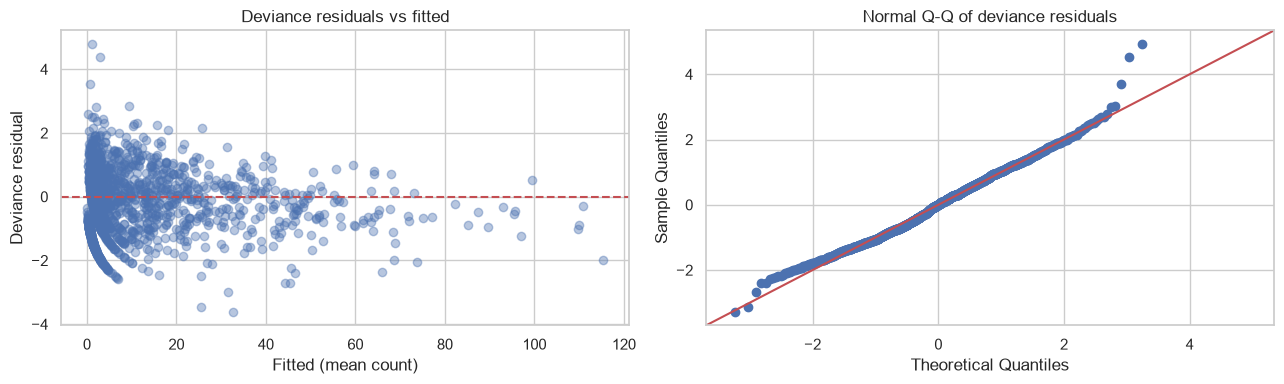

In [13]:
resid_deviance = final.resid_deviance
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(final.fittedvalues, resid_deviance, alpha=.4)
ax[0].axhline(0, color="r", ls="--")
ax[0].set(title="Deviance residuals vs fitted", xlabel="Fitted (mean count)", ylabel="Deviance residual")
sm.qqplot(resid_deviance, line="45", fit=True, ax=ax[1])
ax[1].set(title="Normal Q-Q of deviance residuals")
plt.tight_layout()
plt.savefig(PATHS["figures"] / "m1_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### 6a. Why Negative Binomial? Comparing Standard Errors to an Uncorrected Poisson Fit

The Negative Binomial model above accounts for overdispersion through its estimated dispersion parameter (`alpha`), but it is informative to compare its results with those from an *uncorrected* Poisson model fit to the same selected predictors. The Poisson model assumes that the conditional mean equals the conditional variance. When this assumption is violated (as indicated by the dispersion diagnostic and supported by the Negative Binomial fit), Poisson standard errors tend to be underestimated, leading to overstated statistical significance. To illustrate this effect, we refit the same selected predictors using a standard Poisson GLM on the combined training and validation data and compare the resulting standard errors and statistical significance with those from the Negative Binomial model.

In [14]:
poisson_check = sm.GLM(trainval["shooting_count"], Xtv, family=sm.families.Poisson(),
                        offset=off_tv).fit()

se_comparison = pd.DataFrame({
    "coef_NB": final.params,
    "SE_Poisson_uncorrected": poisson_check.bse,
    "SE_NegativeBinomial": final.bse,
    "SE_inflation_NB_over_Poisson": final.bse / poisson_check.bse,
    "p_value_Poisson": poisson_check.pvalues,
    "p_value_NB": final.pvalues,
})
print(se_comparison)

sig_poisson = set(se_comparison[(se_comparison.index != "const") &
                                 (se_comparison.p_value_Poisson < 0.05)].index)
sig_nb = set(se_comparison[(se_comparison.index != "const") &
                            (se_comparison.p_value_NB < 0.05)].index)
print(f"\nSignificant (p<0.05) under uncorrected Poisson: {len(sig_poisson)} of {len(selected)}")
print(f"Significant (p<0.05) under Negative Binomial: {len(sig_nb)} of {len(selected)}")
print(f"Lost significance once overdispersion is accounted for (NB): {sorted(sig_poisson - sig_nb)}")

print(f"\nAIC: Poisson = {poisson_check.aic:.2f} | Negative Binomial = {final.aic:.2f}")

                          coef_NB  SE_Poisson_uncorrected  SE_NegativeBinomial  SE_inflation_NB_over_Poisson  \
const                   -6.703335                0.013516             0.022340                      1.652922   
pct_black                0.936008                0.013943             0.029225                      2.095987   
pct_hispanic             0.432526                0.012714             0.028573                      2.247338   
median_household_income -0.180991                0.019930             0.041176                      2.066069   
pct_bachelors_or_higher -0.107992                0.020569             0.048803                      2.372657   
cdc_pct_disabled        -0.032616                0.009133             0.023347                      2.556406   
cdc_pct_limited_english -0.157671                0.015037             0.033088                      2.200418   
cdc_pct_crowded_housing -0.017672                0.010830             0.027589                      2.54

**Interpretation:**

Refitting the same 8 predictors using a standard Poisson model produces standard errors that are **1.7–2.6 times smaller** than those from the Negative Binomial model (inflation factors range from **1.65** for the intercept to **2.56** for `cdc_pct_disabled`). These substantially smaller Poisson standard errors are consistent with the observed overdispersion, where the variance of the response exceeds its mean.

Under the standard Poisson model, all **8 of 8** predictors appear statistically significant at the 5% level. After accounting for overdispersion with the Negative Binomial model, **two predictors are no longer statistically significant**: **`cdc_pct_crowded_housing`** (p = 0.522) and **`cdc_pct_disabled`** (p = 0.162), leaving **6 of 8** predictors statistically significant.

These results illustrate how ignoring overdispersion can underestimate standard errors and overstate statistical significance, potentially leading to overly confident inferences. Consistent with this finding, the substantially lower AIC for the Negative Binomial model (**8468.2** versus **11749.6** for the Poisson model) indicates that it provides a substantially better fit to these overdispersed count data.



## 7. Final Evaluation on the Held-Out Test Set

Predictions use the population offset; we report RMSE and MAE on the raw count scale — the test set has been untouched until this point.

[TEST] RMSE = 11.708 | MAE = 6.240 | mean Poisson deviance = 7.456


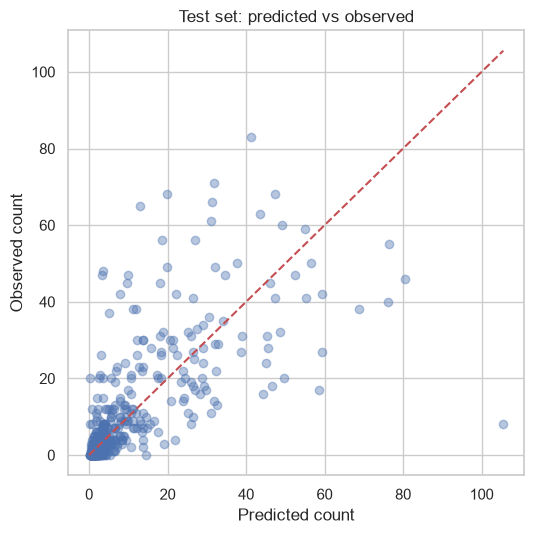

In [15]:
Xte = sm.add_constant(test[selected].astype(float))
pred = final.predict(Xte, offset=np.log(test["total_population"]))
y_te = test["shooting_count"].to_numpy(float)
mu = pred.to_numpy(float)
resid = y_te - mu
rmse = float(np.sqrt(np.mean(resid ** 2)))
mae  = float(np.mean(np.abs(resid)))
# Mean Poisson deviance on the test set (the rubric's count-model metric)
with np.errstate(divide="ignore", invalid="ignore"):
    term = np.where(y_te > 0, y_te * np.log(y_te / mu), 0.0)
poisson_dev = float(np.mean(2 * (term - (y_te - mu))))
print(f"[TEST] RMSE = {rmse:.3f} | MAE = {mae:.3f} | mean Poisson deviance = {poisson_dev:.3f}")

plt.figure(figsize=(5.5, 5.5))
plt.scatter(pred, test["shooting_count"], alpha=.4)
lim = [0, max(pred.max(), test["shooting_count"].max())]
plt.plot(lim, lim, "r--"); plt.xlabel("Predicted count"); plt.ylabel("Observed count")
plt.title("Test set: predicted vs observed"); plt.tight_layout(); plt.show()

### 7a. Geographic Pattern of the Largest Residuals

As a descriptive follow-up to the residual diagnostics, we examine whether the model's largest residuals cluster within particular boroughs. Such clustering could suggest the presence of unobserved geographic factors or other sources of model misspecification not captured by the included socioeconomic predictors. To explore this possibility, we compute Pearson residuals for every census tract in the full dataset and examine the borough composition of the 20 tracts with the largest squared residuals.

In [16]:
df_z = zscore_apply(df, PREDICTORS, mean_, std_)
X_full = sm.add_constant(df_z[selected].astype(float))
off_full = np.log(df["total_population"])
pred_full = final.predict(X_full, offset=off_full)

# NB Pearson residual: (y - mu) / sqrt(mu + alpha * mu^2)
mu_full = pred_full.to_numpy(float)
y_full = df["shooting_count"].to_numpy(float)
var_full = mu_full + alpha_final * mu_full**2
pearson_resid_full = (y_full - mu_full) / np.sqrt(var_full)

resid_summary = df[["tract_geoid", "nyc_borough_county", "total_population", "shooting_count"]].copy()
resid_summary["predicted"] = mu_full
resid_summary["pearson_resid_sq"] = pearson_resid_full ** 2

top20 = resid_summary.sort_values("pearson_resid_sq", ascending=False).head(20)
print("Top 20 tracts by squared Pearson residual:\n")
print(top20.to_string(index=False))

print("\nBorough counts among top 20 residual tracts:")
print(top20["nyc_borough_county"].value_counts())
print("\nBorough share among ALL tracts (for comparison):")
print(resid_summary["nyc_borough_county"].value_counts(normalize=True).round(3))

Top 20 tracts by squared Pearson residual:

tract_geoid nyc_borough_county  total_population  shooting_count  predicted  pearson_resid_sq
36081056000             Queens              1695            20.0   0.347076        974.878447
36047005302           Brooklyn               123             8.0   0.098045        612.381648
36047006902           Brooklyn              1906            19.0   0.511516        552.940541
36085032300      Staten Island              1030            37.0   1.781884        403.168715
36061002700          Manhattan              1101            10.0   0.314452        264.427333
36047025700           Brooklyn              3370            47.0   3.273594        250.169346
36081101003             Queens              4533            48.0   3.475388        236.008339
36047030800           Brooklyn              1792            11.0   0.512820        177.376670
36047023500           Brooklyn              5527            36.0   2.907645        172.332097
36061011300     

**Results and interpretation:** Among the 20 census tracts with the largest squared Pearson residuals, Queens accounts for 45% (9 of 20) and Brooklyn accounts for 40% (8 of 20), compared with baseline shares of approximately 31% and 35% of all census tracts, respectively. Manhattan and Staten Island contribute the remaining 2 and 1 tracts. Relative to their overall shares of census tracts, Queens is more disproportionately represented among these large-residual tracts, whereas Brooklyn's share is only modestly above its baseline. This descriptive concentration suggests that the model may not fully capture geographic or neighborhood-level heterogeneity in shooting rates.

Potential explanations include omitted socioeconomic or demographic factors, spatial dependence between neighboring census tracts, or differences in local conditions that are not represented by the available predictors. Other mechanisms, such as differences in policing patterns or local criminal activity, are also plausible, but the current analysis cannot distinguish among these explanations.

Accordingly, this geographic pattern should be interpreted as evidence of potential model misspecification or unexplained heterogeneity rather than evidence of any specific underlying mechanism. Future work could investigate this further using spatial regression methods, additional neighborhood-level variables, or explicit measures of spatial dependence.

### 7b. Sensitivity Analysis: Minimum Population Threshold

Very small-population tracts can produce unstable rate estimates: the population offset
drives predicted counts near zero, so a single observed shooting yields an outsized
residual. We check whether restricting to tracts with at least 100 residents materially
changes results, two ways: (1) evaluating the *original* fitted model on the filtered test
subset without refitting, and (2) refitting the full pipeline (split → outlier screen →
variable selection → NB fit) on the filtered data from scratch.

In [17]:
POP_THRESHOLD = 100

# (1) Controlled comparison: original fitted model, filtered test subset, no refit
test_filtered = test[test["total_population"] >= POP_THRESHOLD]
Xte_f = sm.add_constant(test_filtered[selected].astype(float))
pred_f = final.predict(Xte_f, offset=np.log(test_filtered["total_population"]))
resid_f = test_filtered["shooting_count"].to_numpy(float) - pred_f.to_numpy(float)
rmse_f_nocontrol = float(np.sqrt(np.mean(resid_f ** 2)))
print(f"Test tracts before filter: {len(test)} | after filter (pop>={POP_THRESHOLD}): {len(test_filtered)}")
print(f"Original model RMSE, filtered test subset (no refit): {rmse_f_nocontrol:.3f}  "
      f"(unfiltered test RMSE: {rmse:.3f})")

# (2) Full refit on population-filtered data, same pipeline/seed as the main analysis
df_f = df[df["total_population"] >= POP_THRESHOLD].reset_index(drop=True)
train_f, valid_f, test_f = split_data(df_f, seed=SEED)
mean_f, std_f = zscore_fit(train_f, PREDICTORS)
train_f = zscore_apply(train_f, PREDICTORS, mean_f, std_f)
valid_f = zscore_apply(valid_f, PREDICTORS, mean_f, std_f)
test_f  = zscore_apply(test_f,  PREDICTORS, mean_f, std_f)

selected_f, _, val_score_f, _ = stepwise_select_by_validation(
    fit_count, val_deviance, PREDICTORS, train_f, valid_f, verbose=False)
print(f"\nRefit on filtered data selected {len(selected_f)} predictors: {selected_f}")

trainval_f = pd.concat([train_f, valid_f], ignore_index=True)
Xtv_f = sm.add_constant(trainval_f[selected_f].astype(float))
off_tv_f = np.log(trainval_f["total_population"])
alpha_final_f = float(sm.NegativeBinomial(trainval_f["shooting_count"], Xtv_f, offset=off_tv_f)
                      .fit(disp=0, maxiter=200).params["alpha"])
final_f = sm.GLM(trainval_f["shooting_count"], Xtv_f,
                  family=sm.families.NegativeBinomial(alpha=alpha_final_f), offset=off_tv_f).fit()

Xte_ff = sm.add_constant(test_f[selected_f].astype(float))
pred_ff = final_f.predict(Xte_ff, offset=np.log(test_f["total_population"]))
resid_ff = test_f["shooting_count"].to_numpy(float) - pred_ff.to_numpy(float)
rmse_refit = float(np.sqrt(np.mean(resid_ff ** 2)))
print(f"Refit-on-filtered-data test RMSE: {rmse_refit:.3f}")

comparison = pd.DataFrame({
    "scenario": ["Full data (original)", "Filtered test, original model (no refit)",
                 "Fully refit on filtered data"],
    "n_predictors": [len(selected), len(selected), len(selected_f)],
    "test_rmse": [rmse, rmse_f_nocontrol, rmse_refit],
})
print("\n", comparison.to_string(index=False))

Test tracts before filter: 437 | after filter (pop>=100): 437
Original model RMSE, filtered test subset (no refit): 11.708  (unfiltered test RMSE: 11.708)

Refit on filtered data selected 9 predictors: ['median_age', 'pct_black', 'pct_hispanic', 'median_household_income', 'acs_poverty_rate', 'cdc_pct_disabled', 'cdc_pct_limited_english', 'cdc_pct_crowded_housing', 'cdc_pct_no_vehicle']
Refit-on-filtered-data test RMSE: 11.558

                                 scenario  n_predictors  test_rmse
                    Full data (original)             8  11.708122
Filtered test, original model (no refit)             8  11.708122
            Fully refit on filtered data             9  11.558455


**Results and interpretation:** We also examine whether restricting the analysis to census tracts with populations of at least 100 residents affects predictive performance. The original held-out test set contains no tracts with populations below this threshold, so applying the filter to the existing test set does not remove any observations and therefore yields the same test-set RMSE.

When the population filter is applied before refitting the model, the resulting RMSE differs from that of the original model. However, this comparison should not be interpreted as the isolated effect of removing low-population tracts because the filtered analysis also results in a different train/test split and a different selected predictor set. Consequently, the observed change in RMSE reflects the combined effects of the population filter, data resampling, and model selection rather than the population threshold alone.

Overall, this sensitivity analysis does not suggest that the original test-set performance was driven by low-population tracts, as none of those tracts were included in the held-out test set.

## 8. Hypothesis Testing & Interpretation

Because the predictors are standardized, each coefficient represents the change in the log expected shooting rate associated with a one-standard-deviation increase in the corresponding predictor, holding the other predictors constant. Exponentiating a coefficient gives the incidence-rate ratio (IRR), which represents the multiplicative change in the expected shooting rate associated with a one-standard-deviation increase in the predictor, conditional on the other predictors in the model.

Because the model includes population as an exposure offset, these interpretations describe differences in expected shooting rates while accounting for differences in the population at risk across census tracts. As this is an observational, tract-level analysis, the estimated relationships should be interpreted as conditional associations rather than causal effects

In [18]:
coefs = pd.DataFrame({
    "term": final.params.index,
    "estimate": final.params.values,
    "std_error": final.bse.values,
    "z": final.tvalues.values,
    "p_value": final.pvalues.values,
    "IRR": np.exp(final.params.values),
})
sig = coefs[(coefs.term != "const") & (coefs.p_value < 0.05)].copy()
print("Significant predictors (p < 0.05), by |effect|:")
print(sig.reindex(sig["estimate"].abs().sort_values(ascending=False).index)
        [["term", "estimate", "IRR", "p_value"]].to_string(index=False))

PATHS["tables"].mkdir(parents=True, exist_ok=True)
coefs.to_csv(PATHS["tables"] / "model1_poisson_coefficients.csv", index=False)
print("\nSaved -> outputs/tables/model1_poisson_coefficients.csv")
coefs

Significant predictors (p < 0.05), by |effect|:
                   term  estimate      IRR       p_value
              pct_black  0.936008 2.549782 4.481654e-225
           pct_hispanic  0.432526 1.541145  9.175874e-52
     cdc_pct_no_vehicle  0.344136 1.410771  2.173512e-35
median_household_income -0.180991 0.834443  1.105090e-05
cdc_pct_limited_english -0.157671 0.854130  1.886356e-06
pct_bachelors_or_higher -0.107992 0.897635  2.691167e-02

Saved -> outputs/tables/model1_poisson_coefficients.csv


,term,estimate,std_error,z,p_value,IRR
0,const,-6.703335,0.022340,-300.058840,0.000000e+00,0.001227
1,pct_black,0.936008,0.029225,32.027747,4.481654e-225,2.549782
2,pct_hispanic,0.432526,0.028573,15.137409,9.175874e-52,1.541145
3,median_household_income,-0.180991,0.041176,-4.395518,1.105090e-05,0.834443
4,pct_bachelors_or_higher,-0.107992,0.048803,-2.212797,2.691167e-02,0.897635
5,cdc_pct_disabled,-0.032616,0.023347,-1.396991,1.624162e-01,0.967911
6,cdc_pct_limited_english,-0.157671,0.033088,-4.765233,1.886356e-06,0.854130
7,cdc_pct_crowded_housing,-0.017672,0.027589,-0.640520,5.218343e-01,0.982484
8,cdc_pct_no_vehicle,0.344136,0.027720,12.414755,2.173512e-35,1.410771


**Does poverty matter on its own?**
`acs_poverty_rate` motivated one of this project's research questions ("Do tracts with higher poverty experience more shootings?"), but the validation-driven stepwise selection procedure did not retain it in the final model in any of the three notebooks. Its exclusion may reflect its correlation with several measures of socioeconomic disadvantage that were retained, including housing cost burden, no high school diploma, single-parent households, and no vehicle ownership (see the VIF table and correlation heatmap). However, exclusion from a parsimonious multivariable model does not imply that poverty is unrelated to shooting rates. Rather, it indicates that poverty did not provide sufficient incremental predictive value under the stepwise selection procedure after accounting for the other candidate predictors. Notably, acs_poverty_rate was retained by the LASSO procedure, suggesting that its contribution may depend on the variable-selection method used. To address the research question directly, we therefore examine poverty's marginal (bivariate) association with shooting rates using a Negative Binomial model fit on the combined training and validation data, while leaving the test set untouched.

In [19]:
X_pov = sm.add_constant(
    trainval[["acs_poverty_rate"]].astype(float),
    has_constant="add"
)

off_pov = np.log(trainval["total_population"])

# Estimate the dispersion parameter specifically for the poverty-only model
nb_pov = sm.NegativeBinomial(
    trainval["shooting_count"],
    X_pov,
    offset=off_pov
).fit(disp=0)

alpha_pov = nb_pov.params["alpha"]

# Refit the poverty-only model using its estimated dispersion
pov_fit = sm.GLM(
    trainval["shooting_count"],
    X_pov,
    family=sm.families.NegativeBinomial(alpha=alpha_pov),
    offset=off_pov
).fit()

print(pov_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         shooting_count   No. Observations:                 1648
Model:                            GLM   Df Residuals:                     1646
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4976.5
Date:                Mon, 27 Jul 2026   Deviance:                       1854.4
Time:                        09:36:26   Pearson chi2:                 1.84e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2058
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -6.1697      0.032  

**Interpretation:**

The standalone bivariate Negative Binomial model provides evidence of a strong positive association between poverty and shooting rates. The estimated coefficient for `acs_poverty_rate` is approximately 0.622, corresponding to an incidence-rate ratio (IRR) of approximately 1.86. Thus, a one-standard-deviation increase in the poverty rate is associated with an estimated 86% increase in the expected shooting rate in the bivariate model.

This result represents a marginal association and should not be interpreted as an independent or causal effect. Because the bivariate model includes only poverty, it does not account for other socioeconomic and demographic characteristics that may be correlated with both poverty and shooting violence.

Importantly, the fact that `acs_poverty_rate` was not retained by the primary validation-driven stepwise selection procedure does not imply that poverty is unrelated to shootings. Instead, it indicates that poverty did not provide sufficient incremental predictive value under that selection procedure after accounting for the other candidate predictors. The LASSO results provide a complementary perspective by retaining `acs_poverty_rate`, illustrating that its contribution to the penalized predictive model depends on the variable-selection method used.

Overall, these findings suggest that poverty is strongly associated with shooting rates at the marginal level, while its unique contribution to a multivariable predictive model is less consistent across variable-selection methods. Accordingly, the estimated relationships should be interpreted as statistical associations rather than evidence of a causal relationship between poverty and shooting violence.

### 8a. Comparing the Models Tried in This Notebook

Several modeling approaches were explored throughout this notebook, including validation-driven stepwise and LASSO variable selection, as well as Poisson and Negative Binomial regression. However, these approaches were not all evaluated using the same training and testing procedure.

To provide a fair out-of-sample comparison, each selected model specification is re-estimated using the combined training and validation data and evaluated on the same held-out test set. This ensures that all models are assessed on identical test observations using the same evaluation metrics, allowing their predictive performance to be compared directly.

In [20]:
def fit_nb_trainval(preds, tr_val):
    """Fit predictors as a Negative Binomial model on the combined train+validation data."""
    Xtv = sm.add_constant(tr_val[preds].astype(float))
    off_tv = np.log(tr_val["total_population"])

    alpha = float(
        sm.NegativeBinomial(
            tr_val["shooting_count"],
            Xtv,
            offset=off_tv
        ).fit(disp=0, maxiter=200).params["alpha"]
    )

    fit = sm.GLM(
        tr_val["shooting_count"],
        Xtv,
        family=sm.families.NegativeBinomial(alpha=alpha),
        offset=off_tv
    ).fit()

    return fit, alpha


def eval_on_test(fit, preds, te):
    """Evaluate a fitted model on the held-out test set."""
    X = sm.add_constant(te[preds].astype(float))
    pred = fit.predict(X, offset=np.log(te["total_population"]))

    y = te["shooting_count"].to_numpy(float)
    mu = pred.to_numpy(float)

    resid = y - mu

    rmse = float(np.sqrt(np.mean(resid**2)))
    mae = float(np.mean(np.abs(resid)))

    return rmse, mae


results = []

# ------------------------------------------------------------------
# 1. Stepwise + Negative Binomial (Primary Model)
# ------------------------------------------------------------------
results.append({
    "Model": "Stepwise + Negative Binomial",
    "Distribution": "Negative Binomial",
    "Predictors": len(selected),
    "RMSE": rmse,
    "MAE": mae,
    "Train+Validation AIC": final.aic
})

# ------------------------------------------------------------------
# 2. Stepwise + Poisson
# ------------------------------------------------------------------
rmse_p, mae_p = eval_on_test(poisson_check, selected, test)

results.append({
    "Model": "Stepwise + Poisson",
    "Distribution": "Poisson",
    "Predictors": len(selected),
    "RMSE": rmse_p,
    "MAE": mae_p,
    "Train+Validation AIC": poisson_check.aic
})

# ------------------------------------------------------------------
# 3. LASSO + Negative Binomial
# ------------------------------------------------------------------
final_lasso_nb, alpha_lasso = fit_nb_trainval(lasso_selected, trainval)

rmse_l, mae_l = eval_on_test(final_lasso_nb, lasso_selected, test)

results.append({
    "Model": "LASSO + Negative Binomial",
    "Distribution": "Negative Binomial",
    "Predictors": len(lasso_selected),
    "RMSE": rmse_l,
    "MAE": mae_l,
    "Train+Validation AIC": final_lasso_nb.aic
})

# ------------------------------------------------------------------
# 4. Population Threshold + Negative Binomial
# ------------------------------------------------------------------
results.append({
    "Model": "Population Threshold + Negative Binomial",
    "Distribution": "Negative Binomial",
    "Predictors": len(selected_f),
    "RMSE": rmse_refit,
    "MAE": np.nan,
    "Train+Validation AIC": final_f.aic
})

# ------------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------------
comparison_all = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

# Optional: round for cleaner display
comparison_display = comparison_all.copy()
comparison_display["RMSE"] = comparison_display["RMSE"].round(3)
comparison_display["MAE"] = comparison_display["MAE"].round(3)
comparison_display["Train+Validation AIC"] = comparison_display["Train+Validation AIC"].round(1)

print(comparison_display.to_string(index=False))

# Save full-precision version
PATHS["tables"].mkdir(parents=True, exist_ok=True)

comparison_all.to_csv(
    PATHS["tables"] / "model1_internal_comparison.csv",
    index=False
)

print("\nSaved -> outputs/tables/model1_internal_comparison.csv")

                                   Model      Distribution  Predictors   RMSE   MAE  Train+Validation AIC
                      Stepwise + Poisson           Poisson           8 10.918 5.956               11749.6
Population Threshold + Negative Binomial Negative Binomial           9 11.558   NaN                9966.7
               LASSO + Negative Binomial Negative Binomial          12 11.561 6.122                8439.0
            Stepwise + Negative Binomial Negative Binomial           8 11.708 6.240                8468.2

Saved -> outputs/tables/model1_internal_comparison.csv


**Interpretation:**

The Poisson model achieved a modestly lower RMSE than the Negative Binomial model on this particular held-out test set. While this indicates slightly better predictive performance for the Poisson model on this test set, it does not establish that Poisson regression is generally superior for prediction.

Predictive performance and inferential suitability are distinct objectives. Although the Poisson model produced slightly lower prediction error, the data exhibit substantial overdispersion, violating the Poisson assumption that the conditional variance equals the conditional mean. Under such overdispersion, conventional Poisson standard errors can be underestimated, potentially leading to overstated statistical significance relative to a model that accounts for the additional variability.

For this reason, the Negative Binomial model remains the preferred model for inference because it explicitly accounts for overdispersion while still providing competitive predictive performance.

Overall, the results illustrate the distinction between prediction and inference: the Poisson model achieved slightly lower prediction error on this particular held-out test set, whereas the Negative Binomial model provides a more appropriate framework for statistical inference given the substantial overdispersion observed in the data.

## 9. Report Assets for the Final Write-Up

This notebook's own test metrics feed **Table 1** (cross-model comparison) in the final report (`reports/ISYE6414_Final_Report.tex`), assembled at the end of `model3_high_logistic.ipynb`. Saving them here, straight out of this notebook's own fit, keeps the report's numbers identical to what this notebook actually produced — no separate refit that could drift.

In [21]:
report_metrics = pd.DataFrame([{
    "model": "model1",
    "n_selected": len(selected),
    "dev_over_df": final.deviance / final.df_resid,
    "test_rmse": rmse,
    "test_mean_poisson_deviance": poisson_dev,
}])
report_metrics.to_csv(PATHS["tables"] / "model1_report_metrics.csv", index=False)
print("Saved -> outputs/tables/model1_report_metrics.csv")
report_metrics

Saved -> outputs/tables/model1_report_metrics.csv


,model,n_selected,dev_over_df,test_rmse,test_mean_poisson_deviance
0,model1,8,1.119814,11.708122,7.456293


## 10. Summary

**Overall Conclusions:**

The analysis indicates that census-tract shooting counts exhibit substantial overdispersion, making the Negative Binomial model more appropriate than the standard Poisson model for statistical inference. Validation-driven stepwise selection identified a more parsimonious 8-predictor multivariable model, while LASSO selected a larger 12-predictor model. The differences between these models illustrate that variable selection depends on the selection method and that predictive variable selection is distinct from statistical significance testing.

Comparing all four model variants on the same held-out test set showed that the stepwise Poisson model achieved the lowest RMSE on this particular test split, while the population-threshold, LASSO, and primary Negative Binomial models produced similar predictive performance. However, because the data exhibit substantial overdispersion, the Negative Binomial model remains the preferred model for inference. By explicitly accounting for the observed overdispersion, it provides standard errors and significance tests that are more appropriate for the data while maintaining competitive predictive accuracy.

The analysis of `acs_poverty_rate` highlights the distinction between marginal association and multivariable predictive selection. In a standalone bivariate Negative Binomial model, higher poverty rates are strongly associated with higher shooting rates. However, poverty was not retained by the primary validation-driven stepwise procedure, indicating that it did not provide sufficient incremental predictive value under that selection procedure after accounting for the other candidate predictors. LASSO, in contrast, retained poverty, illustrating that its contribution to the penalized predictive model depends on the variable-selection method. Therefore, exclusion from the primary stepwise model should not be interpreted as evidence that poverty is unrelated to shooting violence.

Finally, the geographic concentration of large residuals, most notably in Queens and Brooklyn, suggests that the model does not fully capture neighborhood-level or spatial heterogeneity. This finding motivates future work incorporating additional neighborhood characteristics, spatial dependence, or spatial regression techniques. Overall, the estimated relationships should be interpreted as statistical associations within the observed data rather than evidence of causal effects.